# Plot community compositions

Plot community compositions calculated from elementary community modes and from Pycomo for comparison.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
with open("../run_metadata.pkl", "rb") as f:
    run_metadata = pickle.load(f)

simulated_mus = run_metadata["simulated_mus"]
FIXED_UPTAKE = run_metadata["fixed_uptake"]
c_sources = run_metadata["c_sources"]
exchange_pattern = run_metadata["exchange_pattern"]

In [3]:
def to_metabolite_id(ex_id):
    """Convert an exchange reaction id to ecmtool's metabolite id form.
    e.g. 'EX_mal-L_e' -> 'M_mal__45__L_e'
    """
    return ex_id.replace("EX_", "M_", 1).replace("-", "__45__")


def get_c_sources(exchange_pattern, c_sources):
    """For each organism/pattern, return the one uptake reaction that is
    also a carbon source, converted to ecmtool's metabolite id form.
    """
    c_sources = set(c_sources)
    result = {}
    for organism, patterns in exchange_pattern.items():
        result[organism] = {}
        for pattern_name, pattern in patterns.items():
            found = sorted(set(pattern["uptakes"]) & c_sources)
            if len(found) != 1:
                raise ValueError(
                    f"Expected exactly one carbon source in {organism}/{pattern_name}, got {found}"
                )
            result[organism][pattern_name] = to_metabolite_id(found[0])
    return result


def convert_exchange_pattern(exchange_pattern):
    return {
        organism: {
            pattern_name: {
                key: [to_metabolite_id(ex_id) for ex_id in ids]
                for key, ids in pattern.items()
            }
            for pattern_name, pattern in patterns.items()
        }
        for organism, patterns in exchange_pattern.items()
    }


c_sources = get_c_sources(exchange_pattern, c_sources)
converted_pattern = convert_exchange_pattern(exchange_pattern)
c_sources

{'Rhodoferax': {'mEmC_1': 'M_fum_e',
  'mEmC_3': 'M_fum_e',
  'mEmC_2': 'M_cit_e',
  'mEmC_4': 'M_cit_e',
  'mEmC_5': 'M_mal__45__L_e',
  'mEmC_6': 'M_mal__45__L_e',
  'mE_1': 'M_ac_e'},
 'Geobacter': {'mEmC_1': 'M_mal__45__L_e',
  'mEmC_2': 'M_mal__45__L_e',
  'mEmC_3': 'M_mal__45__L_e',
  'mEmC_4': 'M_mal__45__L_e',
  'mEmC_5': 'M_cit_e',
  'mEmC_6': 'M_cit_e',
  'mE_1': 'M_mal__45__L_e'}}

In [4]:
def get_compositions(pattern, mus, plotted_mus, mins=None, maxs=None, organism="Geobacter"):
    """calculate community compositions from the elementary modes.
    If there are too many modes, they are sampled, 
    making sure that the extreme points are always plotted.
    """
    color = "#00a797"
    compute_extrema = mins is None or maxs is None
    max_points = 500_000
    rng = np.random.default_rng(4)
    if compute_extrema:
        mins, maxs, plotted_mus = [], [], []
    for i, mu in enumerate(mus):
        try:
            composition = pd.read_csv(
                f"../results/ecms2comp_{pattern}_{round(mu,2)}.csv",
                index_col=0
            )
        except FileNotFoundError:
            print(f"Results for {pattern} mu={mu} not available")
            continue
        values = composition[organism].to_numpy()
        if compute_extrema:
            plotted_mus.append(mu)
            mins.append(values.min())
            maxs.append(values.max())
        print(pattern, round(mu, 2), len(values))
        # Randomly sample points for plotting only, while always keeping the extremes
        if len(values) > max_points:
            min_idx = np.argmin(values)
            max_idx = np.argmax(values)

            mask = np.ones(len(values), dtype=bool)
            mask[min_idx] = False
            mask[max_idx] = False
            remaining_idx = np.flatnonzero(mask)

            n_sample = max_points - 2
            sampled_idx = rng.choice(remaining_idx, size=n_sample, replace=False)

            plot_idx = np.concatenate([sampled_idx, [min_idx, max_idx]])
            values_plot = values[plot_idx]
        else:
            values_plot = values
        plt.scatter(
            values_plot,
            [mu] * len(values_plot),
            color="black",
            alpha=0.6,
            zorder=2,
            s=7,
            label="EFMs" if i == 0 else None
        )
        
    plotted_mus = np.array(plotted_mus)
    mins = np.array(mins)
    maxs = np.array(maxs)
    
    mask = mins - maxs < -1e-6
    
    plt.fill_betweenx(
        plotted_mus[mask],
        mins[mask],
        maxs[mask],
        alpha=0.5,
        zorder=1,
        color=color,
        label="pycomo"
    )
    plt.legend(loc="lower right")
    plt.xlabel(f"Fraction of {organism}", size=15)
    plt.ylabel("Growth rate", size=15)
    plt.title(f"Pattern {pattern}")
    plt.savefig(
        f"../figures/{pattern}_EFMs.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    return plotted_mus, mins, maxs

In [5]:
pycomo_results = pd.read_csv("../results/pycomo_composition_ranges.csv")

mEmC_1 0.66 142
mEmC_1 0.6 29319
mEmC_1 0.54 15948
mEmC_1 0.47 5940
mEmC_1 0.4 7236
mEmC_1 0.33 367456
mEmC_1 0.27 12654636
mEmC_1 0.2 71584369


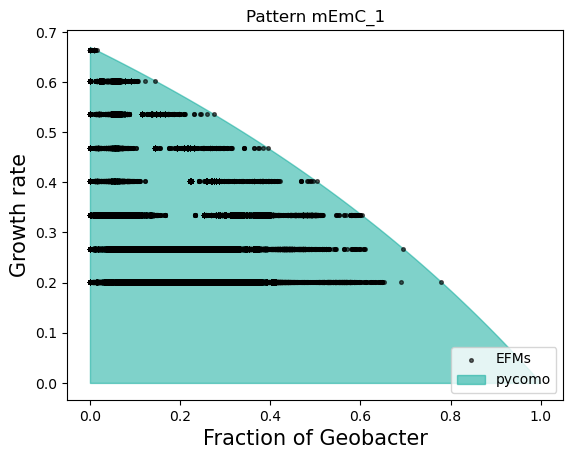

mEmC_3 0.66 40
mEmC_3 0.6 4636
mEmC_3 0.54 5586
mEmC_3 0.47 3492
mEmC_3 0.4 5580
mEmC_3 0.33 348432
mEmC_3 0.27 1171829
mEmC_3 0.2 22630723


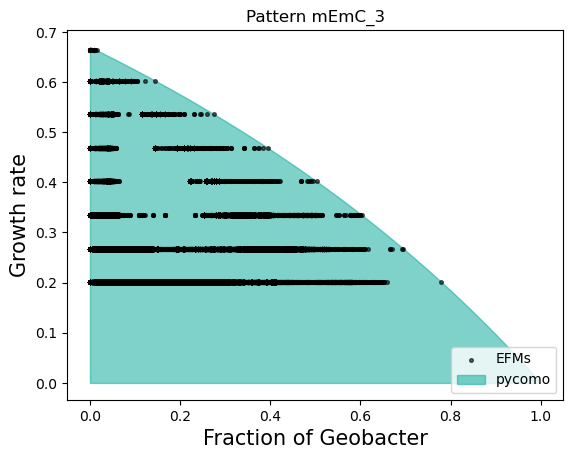

mEmC_2 0.99 22
mEmC_2 0.9 33
mEmC_2 0.8 33
mEmC_2 0.7 183
mEmC_2 0.6 1728
mEmC_2 0.5 12376
mEmC_2 0.4 24340
mEmC_2 0.3 1028577


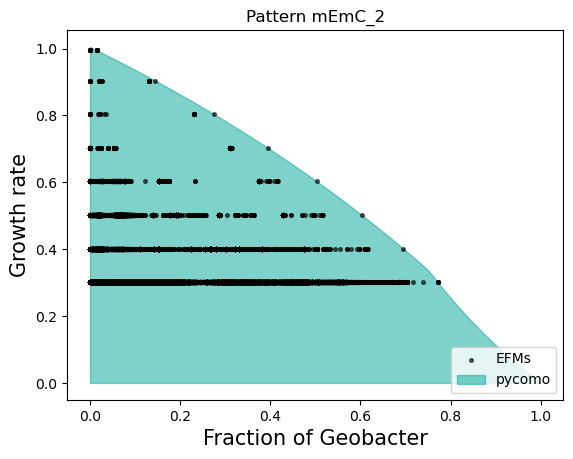

mEmC_4 0.92 3
mEmC_4 0.84 9
mEmC_4 0.74 12
mEmC_4 0.65 518
mEmC_4 0.56 4216
mEmC_4 0.47 8362
mEmC_4 0.37 34498
mEmC_4 0.28 645674


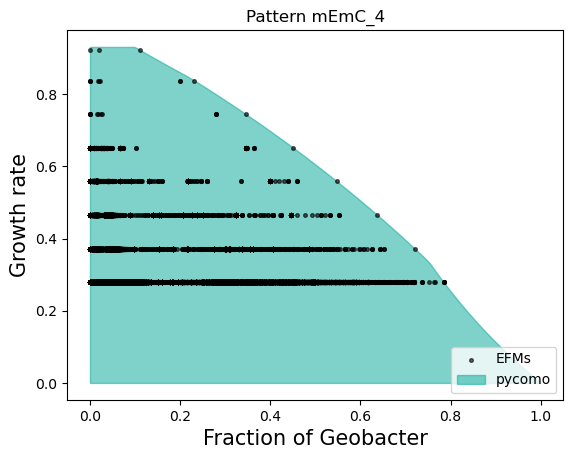

mEmC_5 0.66 2710
mEmC_5 0.6 40520
mEmC_5 0.54 50003
mEmC_5 0.47 52952
mEmC_5 0.4 65368
mEmC_5 0.33 242524
mEmC_5 0.27 770812
mEmC_5 0.2 29788255


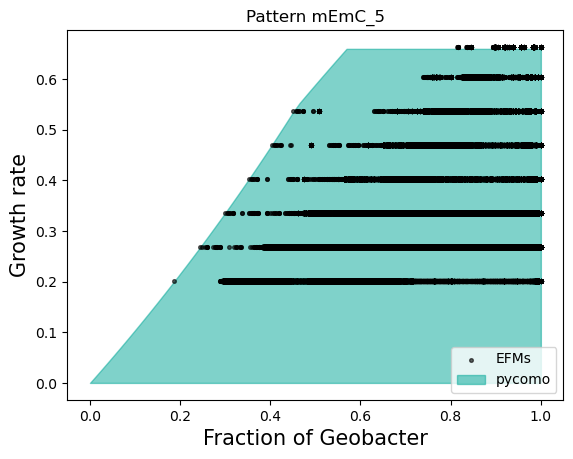

mEmC_6 0.32 5270
mEmC_6 0.29 7602
mEmC_6 0.26 61701
mEmC_6 0.23 286763
mEmC_6 0.2 1016897
mEmC_6 0.16 5941339
mEmC_6 0.13 29884036
mEmC_6 0.1 56619510


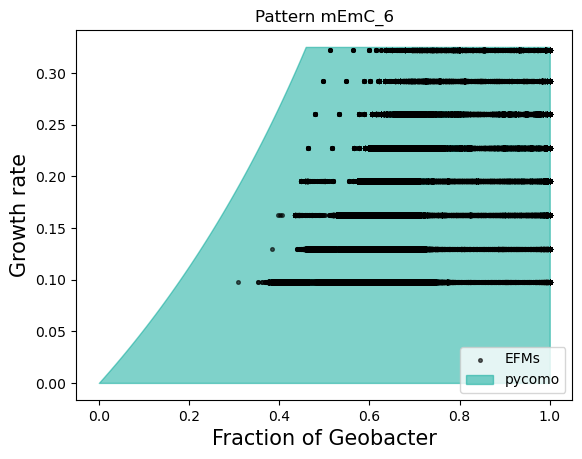

mE_1 0.37 1334
mE_1 0.33 2303
mE_1 0.3 2254
mE_1 0.26 18289
mE_1 0.22 58870
mE_1 0.18 3038257
mE_1 0.15 44599707
Results for mE_1 mu=0.11083393814592404 not available


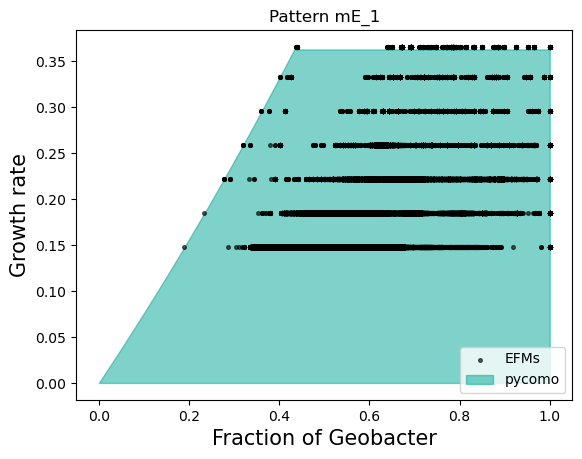

In [6]:
for pattern, mus in simulated_mus.items():
    pycomo_one = pycomo_results[pycomo_results["pattern"] == pattern]
    plotted_mus, mins, maxs = get_compositions(
         pattern, 
         mus, 
         pycomo_one.mu, 
         pycomo_one.min_fraction, 
         pycomo_one.max_fraction)